In [4]:
using Revise

using LinearAlgebra
using SparseArrays
using Dates
using Random
using ProgressBars
using Plots
using Plots.PlotMeasures
using StatsBase
using LaTeXStrings


includet("../julia/src/UnitaryDilation/UnitaryDilation.jl")
includet("../julia/src/PetzMaps.jl")
includet("../julia/src/utils.jl")

using .UnitaryDilation
using .PetzMaps

## Utility Functions

In [5]:
function get_kraus_operators(noise, gamma, t)
  if noise == "amplitude_damping"
    return get_amplitudedamping_operators(gamma, t)
  elseif noise == "dephasing"
    return get_dephasing_operators(gamma, t)
  elseif noise == "bitflip"
    return get_bitflip_operators(gamma, t)
  else
    error("Unknown noise model: $noise")
  end

end

function apply_noise(model, ρ, n_qubits)
  ρf = apply_channel(model.kraus_fwd, ρ, n_qubits)
  # Enforce physicality (hermitianicity and trace 1)
  enforce_physical!(ρf)
  return ρf
end


function recovery(model, ρ)
  ρr, η = apply_petz_collision(model, ρ)
  enforce_physical!(ρr)
  return ρr, η
end

recovery (generic function with 1 method)

## First Check
Test that we can recover Fig.3 in the reference paper with the current implementation of the Petz map and Kraus operators.

==== STARTING experiment with parameters ====
gamma           : 1.0
kwargs          : Base.Pairs{Symbol, Any, NTuple{4, Symbol}, @NamedTuple{logy::Bool, xlims::Tuple{Float64, Float64}, ylims::Tuple{Float64, Float64}, visualize::Bool}}(:logy => true, :xlims => (-0.1, 5.0), :ylims => (0.001, 1.0), :visualize => true)
n_qubits        : [3, 4, 5, 6]
n_states        : 50
noise_model     : dephasing
plot            : true
plot_points     : 0.2:0.2:5.0
time            : 0.1
Experiment 1 with 3-qubits states... completed.
Experiment 2 with 4-qubits states... completed.
Experiment 3 with 5-qubits states... completed.
Experiment 4 with 6-qubits states... completed.

=== END ===



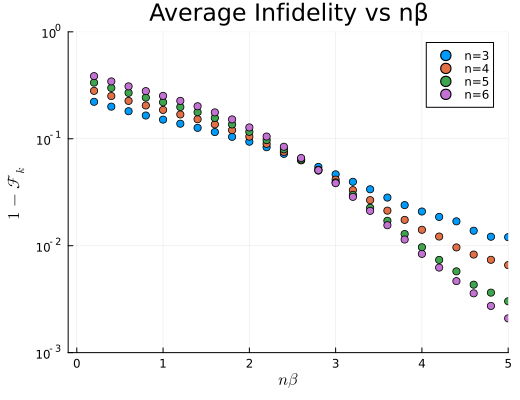

Base.IOError: IOError: pwd(): no such file or directory (ENOENT)

In [23]:
function run_fig3_experiment(
    plot_points,
    n_qubits,
    noise_model ="bitflip";
    n_states    = N_STATES,
    gamma       = GAMMA,
    time        = 0.1,
    plot        = false,
    kwargs...
)

    if !in(noise_model, ["dephasing", "damping", "bitflip"])
        error("Process not known, try with `dephasing` or `decoherence`!")
    end

    println("==== STARTING experiment with parameters ====")
    for (key, val) in sort(collect(Base.@locals), by=x->x[1])
        # rpad aligns the keys to 15 characters for a clean column
        println("$(rpad(key, 15)) : $val")
    end
    println("============================")

    states = []
    recovery_fidelities = []
    
    for (i, n) in enumerate(n_qubits)
        print("Experiment $i with $n-qubits states... ")
        # Find the right beta such that
        # every plot point is n*beta
        betas = plot_points ./ n
        # outer_bar = ProgressBar(betas)
        for beta in betas
            # set_description(outer_bar, "$n/$(round(beta, digits=2))")
            γ = thermal_state(n, beta)
            ψ0 = zeros(ComplexF64, 2^n)
            
            f1s = []
            f2s = []

            for _ in 1:n_states
                ψ0 = random_state(n)
                ρ0 = ψ0 * ψ0'
                ρ1 = deepcopy(ρ0)
                ρ2 = deepcopy(ρ0)

                # Evolve the states
                kraus = get_kraus_operators(noise_model, gamma, time)
                ρ1 = apply_channel(kraus, ρ1, n)
                ρ2 = apply_channel(kraus, ρ2, n)
                # Recover only the second state
                ρ2 = recovery_map(kraus, γ, ρ2, n)

                # Compute fidelity
                f1 = fidelity(ρ0, ρ1)
                f2 = fidelity(ρ0, ρ2)

                append!(f1s, f1)
                append!(f2s, f2)
                push!(states, ψ0)
            end
            # Compute the average fidelity for recovery map
            data = (n, beta, sum(f2s) / length(f2s))
            push!(recovery_fidelities, data)
        end
        print("completed.\n")
    end

    println("\n=== END ===\n")
    
    if plot
        plot_fig3(recovery_fidelities, time; kwargs...)
    end

    return states, recovery_fidelities
end

function plot_fig3(recovery_fidelities, k; logy=false, xlims=(-0.1, 5.0), ylims=(1e-3, 1e0), visualize=true)
    if recovery_fidelities[1][3] isa Dict
        if !(k in keys(recovery_fidelities[1][3]))
            k = collect(keys(recovery_fidelities[1][3]))[k]
        end
    end
    ns = unique(n for (n, _, _) in recovery_fidelities)
    xs = [[n*beta for (n, beta, _) in recovery_fidelities if n == qbts]
           for qbts in ns]
    if recovery_fidelities[1][3] isa Dict
        ys = [[1 - f[k] for (n, _, f) in recovery_fidelities if n==qbts]
                for qbts in ns]
    else
        ys = [[1 - f for (n, _, f) in recovery_fidelities if n==qbts]
                for qbts in ns]
    end

    p = scatter(xs, ys, 
                plot_title = "Average Infidelity vs nβ",
                label = permutedims(["n=$n" for n in ns]),
                xlabel = L"$n\beta$", ylabel=L"$1-\mathcal{F}_k$",
                size=(520, 400))
    plot!(ylims=(0.0, 1.0), xlims=xlims)
    if logy
        # Define log scale values
        tick_values = 10.0 .^ (-10:1:0)

        # Define corresponding labels using LaTeX syntax
        tick_labels = ["10^{$i}" for i in -10:1:0]
        plot!(yscale=:log10, ylims=ylims, yticks=(tick_values, tick_labels))
    end

    if visualize
        display(p)
        #=savefig(p, "../visualization/nb_vs_k$k.pdf")=#
        savefig(p, "../visualization/infidelity/nb_vs_fk$k.png")

        println("Fig 3 saved.")
    end 

    return p
end

plot_points = range(0.2, stop=5.0, length=25)
n_qubits = [3, 4, 5, 6]
_, rf = run_fig3_experiment(
    plot_points, n_qubits, "dephasing";
    n_states    = 50,
    gamma       = 1.0,
    time        = 0.1,
    plot        = true,
    logy        = true,
    xlims       = (-0.1, 5.0),
    ylims       = (1e-3, 1e0),
    visualize   = true
)

## Prove Autorecovery
Select a starting (thermal/random) state and prove if the Petz map can recover it after the application of noise

In [7]:
n_qubits = 2
beta = 3.0
gamma = 1.0
dt = 0.5
noise = "amplitude_damping"
n_steps = 2

2

Initialize the system

In [8]:
# Choose a reference state for the recovery
sigma = thermal_state(n_qubits, beta)
# The initial state is the reference state itself
ρ0 = sigma
sigma

4×4 Matrix{ComplexF64}:
 0.498764+0.0im         0.0+0.0im         0.0+0.0im       0.0+0.0im
      0.0-0.0im  0.00123631+0.0im         0.0+0.0im       0.0+0.0im
      0.0-0.0im         0.0-0.0im  0.00123631+0.0im       0.0+0.0im
      0.0-0.0im         0.0-0.0im         0.0-0.0im  0.498764+0.0im

In [9]:
# Take the relevant Kraus operators
kraus_single_qubit = get_kraus_operators(noise, gamma, dt)
# Build the Petz collision model
# this object store the Kraus operators and the collision Unitary
collision_model = PetzCollisionModel(kraus_single_qubit, sigma, n=n_qubits)
# We also need the superoperators for the Petz map and the noise channel
M_petz, M_noise = build_superoperators(collision_model)
# We start with the noise channel first
M_total = M_noise
size(M_total)
# Test the autorecovery
begin
    sigma_rec = M_petz * M_noise * vec(sigma)
    sigma_rec = reshape(sigma_rec, size(sigma))
    precision = 5e-10
    if isapprox(sigma_rec, sigma; atol=precision)
        println("Autorecovery works with precision $precision")
    else
        println("Autorecovery failed with precision $precision")
    end
    println("Fidelity between sigma and recovered sigma: ", fidelity(sigma, sigma_rec))
end

Autorecovery works with precision 5.0e-10
Fidelity between sigma and recovered sigma: 0.9999999996000004


### Step 1
We apply the noise and recover the state, both with the collision model and the standard Petz map.
- `rho1`: control state where only noise is applied,
- `rho2`: state where noise + collision is applied,
- `rho3`: state where noise + Petz map is applied
---
First, we check that the Kraus operators extension performed in the `PetzCollisionModel` constructor is valid.
While our standard is to apply single-qubit Kraus operators to each qubit independently, this extension creates global Kraus operators for the multipartite state.

In [10]:
rho1 = copy(ρ0)
rho2 = copy(ρ0)
rho3 = copy(ρ0)

rho1 = apply_channel(kraus_single_qubit, rho1, n_qubits)
rho2 = apply_channel(kraus_single_qubit, rho2, n_qubits)
rho3 = apply_channel(collision_model.kraus_fwd, rho3)

if isapprox(rho1, rho2, atol=1e-10) && isapprox(rho2, rho3, atol=1e-10)
    println("All methods give the same result.")
else
    println("Results differ between methods.")
end

All methods give the same result.


Then, we recover `rho2` and `rho3` with the two different methods.

In [11]:
rho2 = recovery_map(kraus_single_qubit, sigma, rho2, n_qubits)
rho3, η = apply_petz_collision(collision_model, rho3)

f1 = fidelity(rho1, ρ0)
f2 = fidelity(rho2, ρ0)
f3 = fidelity(rho3, ρ0)
println("Fidelity after recovery map: ", f2)
println("Fidelity after Petz collision: ", f3)

Fidelity after recovery map: 1.0
Fidelity after Petz collision: 0.939603009233651


Now we can iterate in time

Fidelity after direct noise: 0.49876368842168234
Fidelity after recovery map: 1.0
Fidelity after Petz collision: 0.8685807650460488


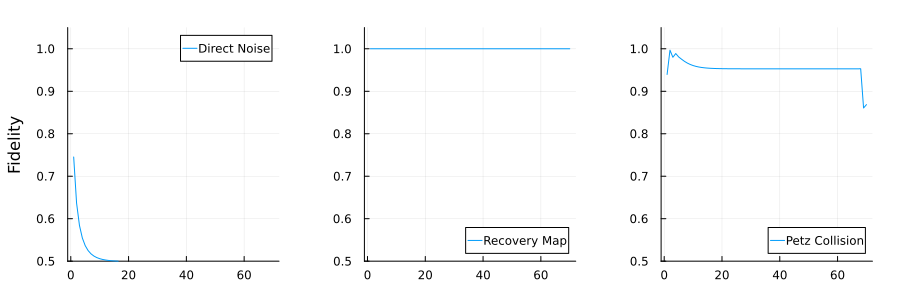

In [12]:
steps = 70
f1s = Float64[f1]
f2s = Float64[f2]
f3s = Float64[f3]
for i in 2:steps
    rho1 = apply_channel(kraus_single_qubit, rho1, n_qubits)
    
    rho2 = apply_channel(kraus_single_qubit, rho2, n_qubits)
    rho2 = recovery_map(kraus_single_qubit, sigma, rho2, n_qubits)
    # Here we have the collision between one application of noise and the other,
    # so we must account for it too in the recovery map
    M_total = M_noise * M_petz * M_total
    collision_model = PetzCollisionModel(M_total, sigma)
    rho3 = apply_channel(collision_model.kraus_fwd, rho3)
    rho3, η = apply_petz_collision(collision_model, rho3)
    
    push!(f1s, fidelity(rho1, ρ0))
    push!(f2s, fidelity(rho2, ρ0))
    push!(f3s, fidelity(rho3, ρ0))
end
println("Fidelity after direct noise: ", f1s[end])
println("Fidelity after recovery map: ", f2s[end])
println("Fidelity after Petz collision: ", f3s[end])

# Set a fixed y-limit so the plot doesn't zoom in on floating point noise
p1 = plot(1:steps, f1s, label="Direct Noise", ylabel="Fidelity", ylims=(0.5, 1.05))
p2 = plot(1:steps, f2s, label="Recovery Map", ylims=(0.5, 1.05))
p3 = plot(1:steps, f3s, label="Petz Collision", ylims=(0.5, 1.05))

plot(p1, p2, p3, layout=(1, 3), size=(900,300), margin=5mm)

We put all this workflow in a single function

In [13]:
function run_experiment(sigma, ρ0, steps; 
    dt=0.1, gamma=1.0, noise="amplitude_damping", n_qubits=1, verbose=true)
    f1s = Float64[]
    f2s = Float64[]
    f3s = Float64[]

    rho1 = deepcopy(ρ0)
    rho2 = deepcopy(ρ0)
    rho3 = deepcopy(ρ0)

    # Take the relevant Kraus operators
    kraus_single_qubit = get_kraus_operators(noise, gamma, dt)
    # Build the Petz collision model
    # this object store the Kraus operators and the collision Unitary
    collision_model = PetzCollisionModel(kraus_single_qubit, sigma, n=n_qubits)
    # We also need the superoperators for the Petz map and the noise channel
    M_petz, M_noise = build_superoperators(collision_model)
    # We start with the noise channel first
    M_total = M_noise

    for i in 1:steps
        rho1 = apply_channel(kraus_single_qubit, rho1, n_qubits)
        
        rho2 = apply_channel(kraus_single_qubit, rho2, n_qubits)
        rho2 = recovery_map(kraus_single_qubit, sigma, rho2, n_qubits)
        # For rho3 we have the collision between one application of noise and the other,
        # so we must account for it too in the recovery map
        if i == 1
            M_total = M_noise
        else
            M_total = M_noise * M_petz * M_total
        end
        collision_model = PetzCollisionModel(M_total, sigma)
        rho3 = apply_channel(collision_model.kraus_fwd, rho3)
        rho3, η = apply_petz_collision(collision_model, rho3)
        
        push!(f1s, fidelity(rho1, ρ0))
        push!(f2s, fidelity(rho2, ρ0))
        push!(f3s, fidelity(rho3, ρ0))
    end
    if verbose
    println("Fidelity after direct noise: ", f1s[end])
    println("Fidelity after recovery map: ", f2s[end])
    println("Fidelity after Petz collision: ", f3s[end])
    end

    # Set a fixed y-limit so the plot doesn't zoom in on floating point noise
    p1 = plot(1:steps, f1s, label="Direct Noise", ylabel="Fidelity", ylims=(0.0, 1.05))
    p2 = plot(1:steps, f2s, label="Recovery Map", ylims=(0.0, 1.05))
    p3 = plot(1:steps, f3s, label="Petz Collision", ylims=(0.0, 1.05))
    
    if verbose
        display(plot(p1, p2, p3, layout=(1, 3), size=(900,300), margin=5mm))
    end

    return (f1s, f2s, f3s), (p1, p2, p3)
end


run_experiment (generic function with 1 method)

Fidelity after direct noise: 0.49111070280558317
Fidelity after recovery map: 0.9999999999999933
Fidelity after Petz collision: 0.9509790138682888


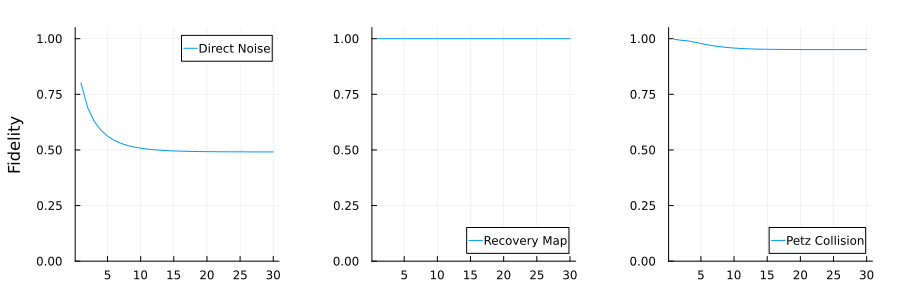

(([0.8013116118025968, 0.6910707565863149, 0.6285266769505955, 0.588829220744228, 0.5620495889353422, 0.5433455493661565, 0.5299859503550345, 0.5202876649906308, 0.513157079813502, 0.5078593627349574  …  0.4919990841893846, 0.49176709309216227, 0.4916003027208728, 0.4914698687070121, 0.49136796083103185, 0.4912883974405046, 0.49122631370699854, 0.4911778902722697, 0.4911401340584096, 0.49111070280558317], [1.0000000000000004, 1.0, 0.9999999999999996, 0.9999999999999996, 0.9999999999999996, 0.9999999999999991, 0.9999999999999987, 0.9999999999999982, 0.9999999999999978, 0.9999999999999978  …  0.9999999999999956, 0.9999999999999951, 0.9999999999999947, 0.9999999999999942, 0.9999999999999942, 0.9999999999999942, 0.999999999999994, 0.9999999999999938, 0.9999999999999938, 0.9999999999999933], [0.9969246340430633, 0.9929869969747946, 0.9902649616037333, 0.9845216031224197, 0.9783634579616691, 0.9725415595291109, 0.9675547206241648, 0.9634906612324459, 0.9602981273808968, 0.957853036840223  … 

In [14]:
beta = 2.0
sigma = thermal_state(n_qubits, beta)
ρ0 = sigma
n_qubits = 2
fids, exp_plots = run_experiment(sigma, ρ0, 30; dt=0.5, gamma=gamma, n_qubits=n_qubits,noise=noise, verbose=true)

## Recovery of a Random State
Iterate these tests for different variations of parameters

### Recovery vs Beta

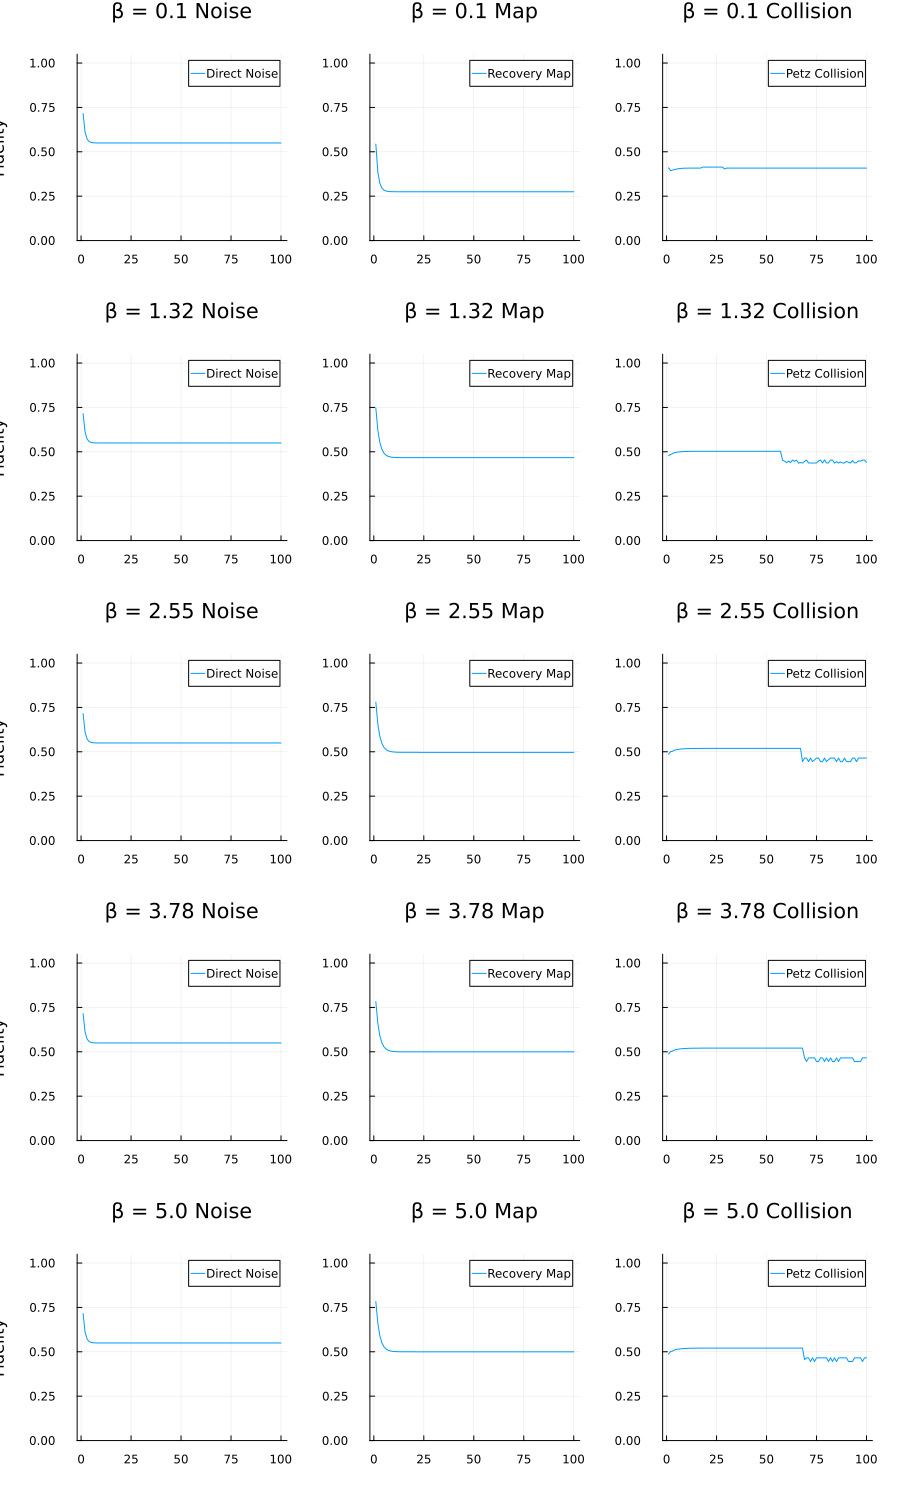

In [15]:
exp_plots = []
titles = []
betas = range(0.1, stop=5.0, length=5)
n_qubits = 2
for beta in betas
    sigma = thermal_state(n_qubits, beta)
    ψ0 = random_state(n_qubits, seed=42)
    ρ0 = ψ0 * ψ0'
    f, p = run_experiment(
        sigma, ρ0, 100; dt=0.5, gamma=gamma, n_qubits=n_qubits, noise=noise, verbose=false)
    append!(exp_plots, p)
    append!(titles, ["β = $(round(beta, digits=2)) $plot_type" for plot_type in ["Noise", "Map", "Collision"]])
end
plot(exp_plots..., 
    layout=(length(betas), 3), 
    size=(900,300*length(betas)), 
    margin=5mm, title=reshape(titles, 1, :))

### Recovery vs Random State
We try to reproduce Figure 3

In [16]:
plot_points = range(0.1, stop=5.0, length=25)
avg_fidelities = []
n_states = 50
n_qubits = [3, 4, 5]

for nb in plot_points
    for n in n_qubits
        beta = nb / n
        fidelities = Float64[0, 0, 0]
        for i in 1:n_states
            sigma = thermal_state(n, beta)
            ψ0 = random_state(n)
            ρ0 = ψ0 * ψ0'
            f, _ = run_experiment(
                sigma, ρ0, 1; dt=0.1, n_qubits=n, gamma=gamma, noise=noise, verbose=false)
            fidelities .= fidelities .+ [e[1] for e in f]
        end
        fidelities = fidelities ./ n_states
        data = (n, beta, fidelities)
        push!(avg_fidelities, data)
    end
end

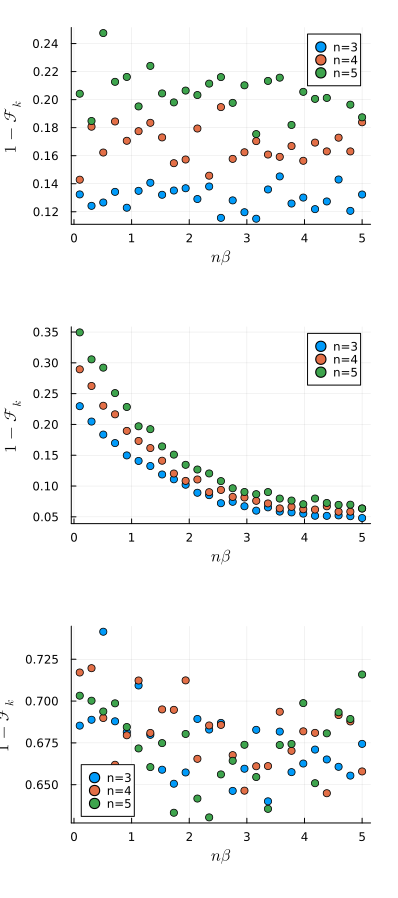

In [18]:
plots = []
xs = []
ys = []
for i in 1:3
    data = [[a, b, c[i]] for (a, b, c) in avg_fidelities]
    xs = plot_points
    ns = transpose(unique(Int(d[1]) for d in data))
    ys = [1 - d[3] for d in data]
    ys = transpose(reshape(ys, 3, :))
    p = scatter(xs, ys, label=["n=$n" for n in ns],
     xlabel=L"$n\beta$", ylabel=L"$1-\mathcal{F}_k$")
    push!(plots, p)
end
p = plot(plots..., layout=(length(n_qubits), 1), size=(400,900), margin=5mm)

==== STARTING experiment with parameters ====
gamma           : 1.0
kwargs          : Base.Pairs{Symbol, Any, NTuple{4, Symbol}, @NamedTuple{logy::Bool, xlims::Tuple{Float64, Float64}, ylims::Tuple{Float64, Float64}, visualize::Bool}}(:logy => true, :xlims => (-0.1, 5.0), :ylims => (0.001, 1.0), :visualize => false)
n_qubits        : [2, 3, 4, 5]
n_states        : 40
noise_model     : dephasing
plot_points     : 0.2:0.25263157894736843:5.0
show_plot       : true
time            : 0.1
Experiment 1 with 2-qubits states... completed.
Experiment 2 with 3-qubits states... completed.
Experiment 3 with 4-qubits states... completed.
Experiment 4 with 5-qubits states... completed.

=== END ===



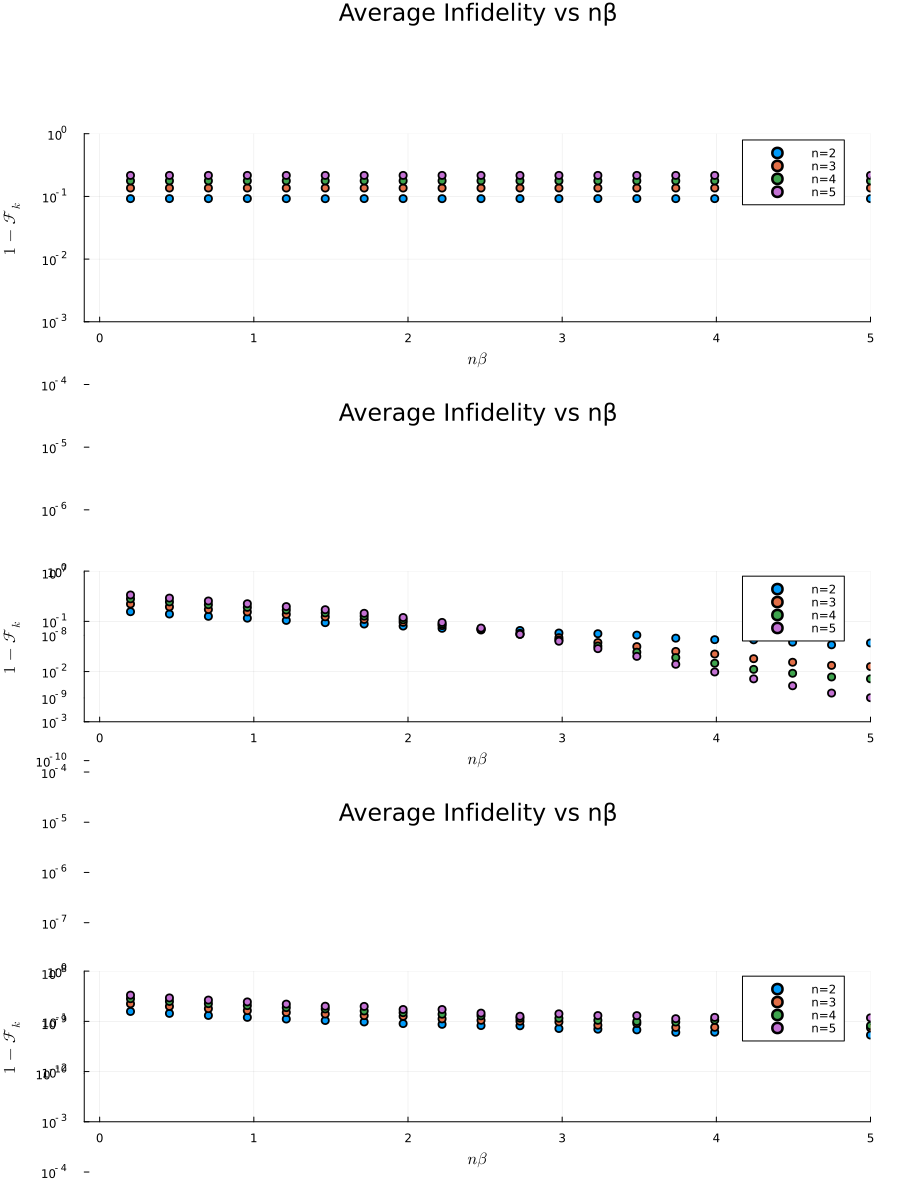

In [29]:
function run_new_experiment(
    plot_points,
    n_qubits,
    noise_model ="bitflip";
    n_states    = N_STATES,
    gamma       = GAMMA,
    time        = 0.1,
    show_plot   = false,
    kwargs...
)

    println("==== STARTING experiment with parameters ====")
    for (key, val) in sort(collect(Base.@locals), by=x->x[1])
        # rpad aligns the keys to 15 characters for a clean column
        println("$(rpad(key, 15)) : $val")
    end
    println("============================")

    states = []
    noise_fidelities = []
    recovery_fidelities = []
    collision_fidelities = []
    
    for (i, n) in enumerate(n_qubits)
        print("Experiment $i with $n-qubits states... ")
        # Find the right beta such that
        # every plot point is n*beta
        betas = plot_points ./ n
        # outer_bar = ProgressBar(betas)
        for beta in betas
            # set_description(outer_bar, "$n/$(round(beta, digits=2))")
            γ = thermal_state(n, beta)
            ψ0 = zeros(ComplexF64, 2^n)
            
            f1s = []
            f2s = []
            f3s = []

            for _ in 1:n_states
                ψ0 = random_state(n)
                ρ0 = ψ0 * ψ0'
                ρ1 = deepcopy(ρ0)
                ρ2 = deepcopy(ρ0)
                ρ3 = deepcopy(ρ0)

                # Evolve the states
                kraus = get_kraus_operators(noise_model, gamma, time)
                collision_model = PetzCollisionModel(kraus, γ, n=n)

                ρ1 = apply_channel(kraus, ρ1, n)
                ρ2 = apply_channel(kraus, ρ2, n)
                ρ3 = apply_channel(collision_model.kraus_fwd, ρ3)
                # Recover only the second state and third state (with the collision)
                ρ2 = recovery_map(kraus, γ, ρ2, n)
                ρ3, η = apply_petz_collision(collision_model, ρ3)

                # Compute fidelity
                f1 = fidelity(ρ0, ρ1)
                f2 = fidelity(ρ0, ρ2)
                f3 = fidelity(ρ0, ρ3)
                append!(f1s, f1)
                append!(f2s, f2)
                append!(f3s, f3)
                push!(states, ψ0)
            end
            # Compute the average fidelity for recovery map
            data1 = (n, beta, sum(f1s) / length(f1s))
            data2 = (n, beta, sum(f2s) / length(f2s))
            data3 = (n, beta, sum(f3s) / length(f3s))
            push!(noise_fidelities, data1)
            push!(recovery_fidelities, data2)
            push!(collision_fidelities, data3)
        end
        print("completed.\n")
    end

    println("\n=== END ===\n")
    
    if show_plot
        p1 = plot_fig3(noise_fidelities, time; kwargs...)
        p2 = plot_fig3(recovery_fidelities, time; kwargs...)
        p3 = plot_fig3(collision_fidelities, time; kwargs...)
        display(plot(p1, p2, p3, layout=(3, 1), size=(900,1200), margin=5mm))
    end

    return states, noise_fidelities, recovery_fidelities, collision_fidelities
end

plot_points = range(0.2, stop=5.0, length=20)
n_qubits = [2, 3, 4, 5]
output = run_new_experiment(
    plot_points, n_qubits, "dephasing";
    n_states    = 40,
    gamma       = 1.0,
    time        = 0.1,
    show_plot   = true,
    logy        = true,
    xlims       = (-0.1, 5.0),
    ylims       = (1e-3, 1e0),
    visualize = false,
);

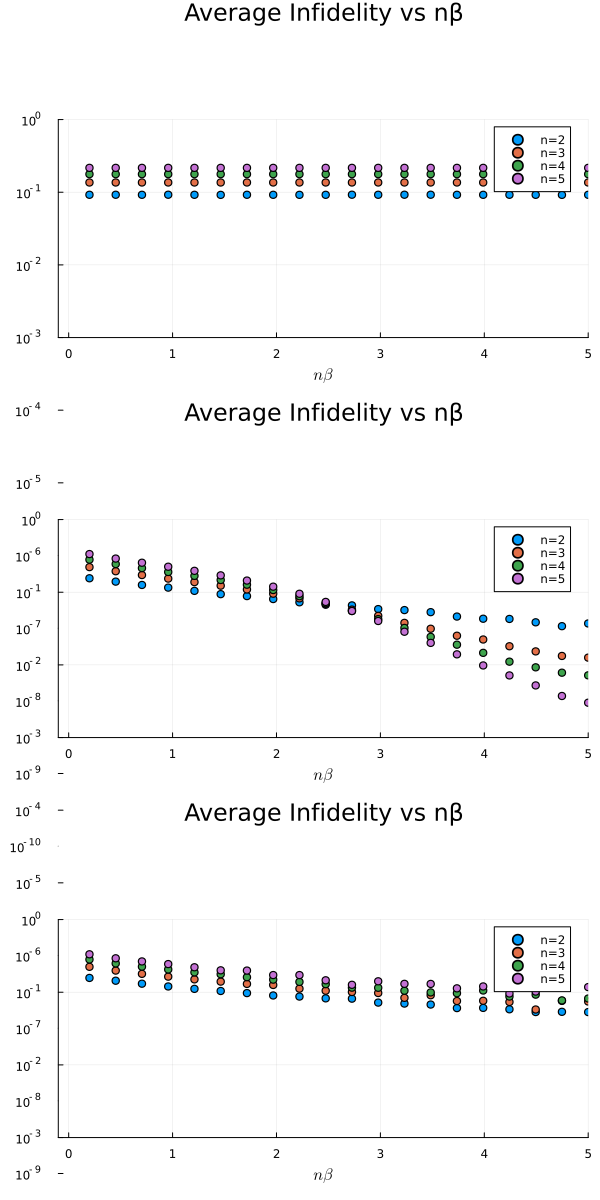

In [35]:
kwargs = (logy=true, xlims=(-0.1, 5.0), ylims=(1e-3, 1e0), visualize=false)
p1 = plot_fig3(output[2], time; kwargs...)
p2 = plot_fig3(output[3], time; kwargs...)
p3 = plot_fig3(output[4], time; kwargs...)
plot(p1, p2, p3, layout=(3, 1), size=(600,1200))